In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Data Exploration: Understanding the Raw Measurements

Before we attempt to mathematically "de-embed" our Device Under Test (DUT) from the test fixtures, we need to understand what our raw data looks like. In RF engineering, measurements are taken using a Vector Network Analyzer (VNA), which outputs **Scattering Parameters (S-parameters)**. 

For a 2-port network, we have four main S-parameters:
* **$S_{11}$ & $S_{22}$ (Reflection):** How much signal bounces back from the input/output.
* **$S_{21}$ & $S_{12}$ (Transmission):** How much signal successfully travels through the device.

Let's load our raw data in to a pandas dataframe, and load the frequencies column for plotting.

In [12]:
df = pd.read_csv("../measurement_data/dut_plus_fixture.csv")
frequencies = df["frequency_Hz"].values

## 1. Reflection / Return Loss ($S_{11}$ & $S_{22}$)

Return Loss measures the power reflected back toward the source due to impedance mismatches. 
* **$S_{11}$** represents reflection at Port 1.
* **$S_{22}$** represents reflection at Port 2.

Since our test setup and fixtures are physically symmetric, the reflections at both ports should be virtually identical ($S_{11} \approx S_{22}$). Let's plot them together to verify this symmetry.

Return Loss is a measure of the power reflected back toward the source due to an impedance mismatch in a transmission line or optical fiber. It is the ratio of incident power to reflected power, typically expressed in decibels (dB). In RF engineering, it is derived from the reflection coefficient, $S_{11}$:

\begin{equation}
S_{11} = \frac{incident}{reflected}
\end{equation}

#### Magnitude of $S_{11}$
Given the real and imaginary components from the dataset ($S_{11} = \text{Re} + j\text{Im}$), the magnitude $|S_{11}|$ is calculated as:

\begin{equation}
|S_{11}| = \sqrt{S_{11,real}^2 + S_{11,imag}^2}
\end{equation}

#### Return Loss Calculation (dB)
Return Loss is defined as the negative magnitude of the reflection coefficient in decibels:

\begin{equation}
S_{11}(\text{dB}) = -20 \log_{10}(|S_{11}|)
\end{equation}

*Note: In practice, while $S_{11}$ is mathematically negative, Return Loss is often expressed as a positive scalar representing the magnitude of that "loss."

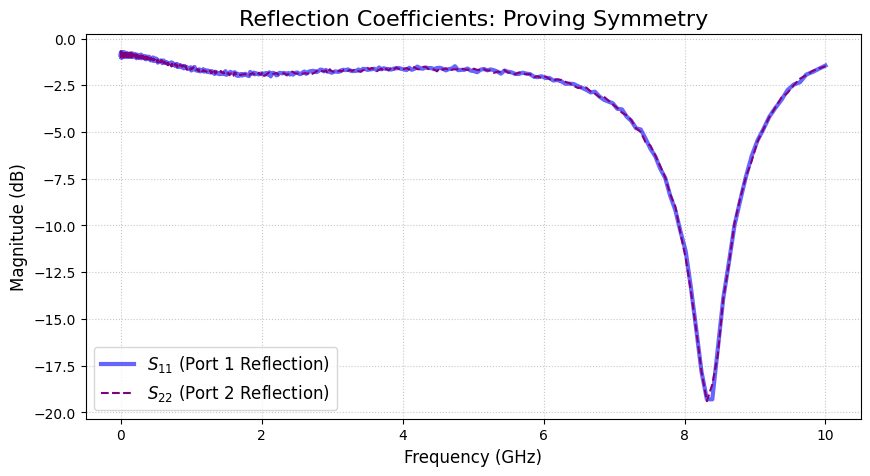

In [13]:
# Calculate S11
s11_mag = np.sqrt(df["S11_real"]**2 + df["S11_imag"]**2)
s11_db = 20 * np.log10(s11_mag + 1e-12)

# Calculate S22
s22_mag = np.sqrt(df["S22_real"]**2 + df["S22_imag"]**2)
s22_db = 20 * np.log10(s22_mag + 1e-12)

plt.figure(figsize=(10, 5))
plt.plot(frequencies / 1e9, s11_db, label="$S_{11}$ (Port 1 Reflection)", color="blue", linewidth=3, alpha=0.6)
plt.plot(frequencies / 1e9, s22_db, label="$S_{22}$ (Port 2 Reflection)", color="purple", linewidth=1.5, linestyle='--')

plt.title("Reflection Coefficients: Proving Symmetry", fontsize=16)
plt.xlabel("Frequency (GHz)", fontsize=12)
plt.ylabel("Magnitude (dB)", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

## 2. Transmission / Insertion Loss ($S_{21}$ & $S_{12}$)

Transmission coefficients measure how much signal successfully travels through the device.
* **$S_{21}$ (Forward):** Signal injected at Port 1, measured at Port 2.
* **$S_{12}$ (Reverse):** Signal injected at Port 2, measured at Port 1.

Because passive components do not amplify signals and do not have directional dependencies, they are **reciprocal**. This means $S_{21}$ must equal $S_{12}$. Let's plot them to confirm our setup is reciprocal.

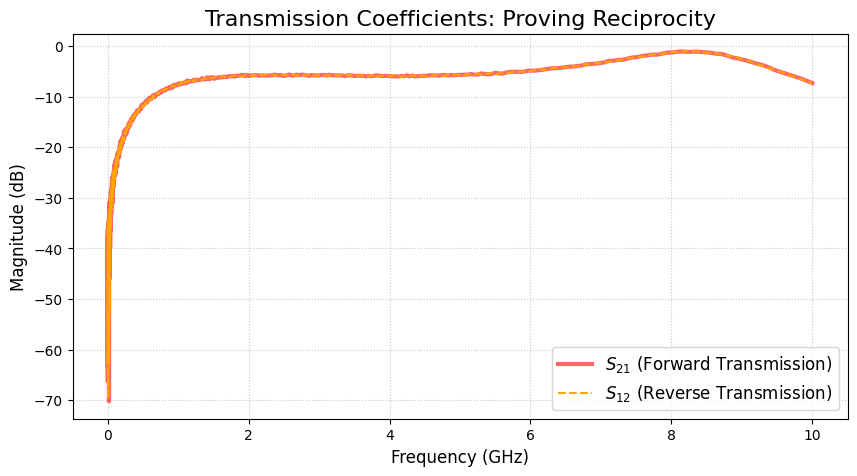

In [14]:
# Изчисляваме S21
s21_mag = np.sqrt(df["S21_real"]**2 + df["S21_imag"]**2)
s21_db = 20 * np.log10(s21_mag + 1e-12)

# Изчисляваме S12
s12_mag = np.sqrt(df["S12_real"]**2 + df["S12_imag"]**2)
s12_db = 20 * np.log10(s12_mag + 1e-12)

plt.figure(figsize=(10, 5))
plt.plot(frequencies / 1e9, s21_db, label="$S_{21}$ (Forward Transmission)", color="red", linewidth=3, alpha=0.6)
plt.plot(frequencies / 1e9, s12_db, label="$S_{12}$ (Reverse Transmission)", color="orange", linewidth=1.5, linestyle='--')

plt.title("Transmission Coefficients: Proving Reciprocity", fontsize=16)
plt.xlabel("Frequency (GHz)", fontsize=12)
plt.ylabel("Magnitude (dB)", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

## Impact of Measurement Fixtures on RF Transmission

The plot below compares the **ideal transmission response of the DUT** with the **raw measurement obtained through fixtures**.  
The transmission parameter being analyzed is **S₂₁**, which describes how much of the input signal at Port 1 is transmitted to Port 2.

In RF systems:

- **|S₂₁| ≈ 1 (0 dB)** means nearly all power is transmitted.
- **|S₂₁| < 1 (negative dB)** indicates losses in the system.

The green curve represents the **Golden DUT response**, which corresponds to the intrinsic behavior of the device without any measurement artifacts.

The red curve represents the **raw measurement**, which includes:

- fixture parasitics
- impedance mismatch
- measurement noise

### Observations

Several important effects can be observed:

1. **Low-frequency attenuation**

   At very low frequencies, both curves start with strong attenuation.  
   This behavior is expected because reactive elements behave like open/short circuits at DC limits.

2. **Fixture-induced loss**

   Across most of the spectrum, the raw measurement (red curve) remains several dB below the ideal DUT response.  
   This difference represents **loss and mismatch introduced by the measurement fixtures**.

3. **Resonant behavior**

   The dashed vertical line marks the **transmission rise around 8 GHz**.  
   Around this region the DUT exhibits maximal transmission, approaching **0 dB** in the ideal case.

4. **Frequency-dependent distortion**

   At higher frequencies (>8 GHz), the raw measurement begins to deviate more strongly.  
   This reflects the increasing influence of:

   - transmission line effects
   - parasitic capacitances
   - imperfect fixture impedance matching.

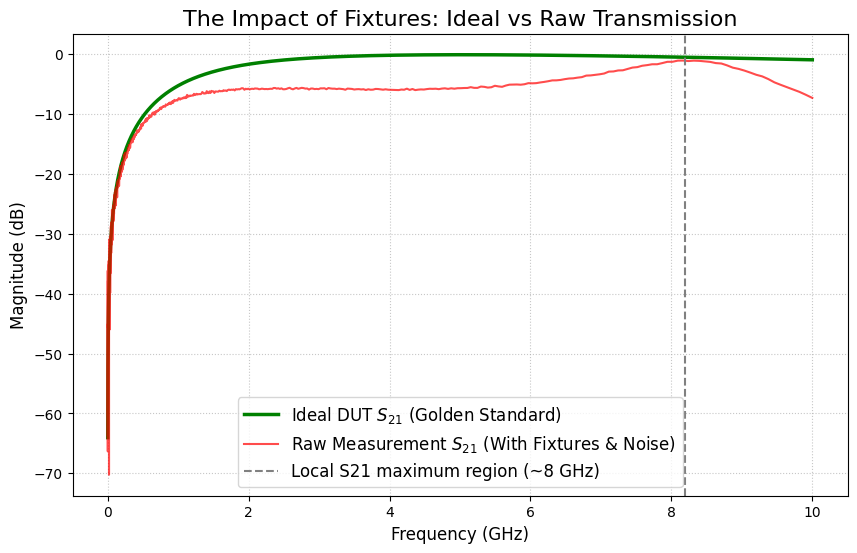

In [ ]:
# Load the ideal data for comparison
df_golden = pd.read_csv("../measurement_data/golden_dut.csv")

# Calculate Golden S21 in dB
s21_gold_mag = np.sqrt(df_golden["S21_real"]**2 + df_golden["S21_imag"]**2)
s21_gold_db = 20 * np.log10(s21_gold_mag + 1e-12)

plt.figure(figsize=(10, 6))
plt.plot(frequencies / 1e9, s21_gold_db, label="Ideal DUT $S_{21}$ (Golden Standard)", color="green", linewidth=2.5)
plt.plot(frequencies / 1e9, s21_db, label="Raw Measurement $S_{21}$ (With Fixtures & Noise)", color="red", alpha=0.7)

plt.title("The Impact of Fixtures: Ideal vs Raw Transmission", fontsize=16)
plt.xlabel("Frequency (GHz)", fontsize=12)
plt.ylabel("Magnitude (dB)", fontsize=12)

plt.axvline(x=8.3, color='gray', linestyle='--', label='Local S21 maximum region (~8 GHz)')

plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()